tensor(0.0010)
5g-mobiwatch abnormal
(120, 570)
(120, 5, 95)
(120, 95)
     rnti     tmsi                     msg
5     762  1777776  Authenticationresponse
6     762  1777776     Securitymodecommand
7     762  1777776    Securitymodecomplete
8     762  1777776     SecurityModeCommand
9     762  1777776    SecurityModeComplete
10  63968  1777776         RRCSetupRequest

     rnti     tmsi                   msg
6     762  1777776   Securitymodecommand
7     762  1777776  Securitymodecomplete
8     762  1777776   SecurityModeCommand
9     762  1777776  SecurityModeComplete
10  63968  1777776       RRCSetupRequest
11  61850   246912       RRCSetupRequest

     rnti     tmsi                   msg
7     762  1777776  Securitymodecomplete
8     762  1777776   SecurityModeCommand
9     762  1777776  SecurityModeComplete
10  63968  1777776       RRCSetupRequest
11  61850   246912       RRCSetupRequest
12  61850   246912              RRCSetup

     rnti     tmsi                   msg
8     762 

/Users/syeda/MobiWatch/src/ai/lstm/lstm_multivariate.py:136: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  X_test = torch.tensor(list(X_test), dtype=torch.float).to(device)
/var/folders/s3/nn8rqkp92c3413g9w6xsc9y00000gn/T/ipykernel_30255/4242441070.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  anomalies = torch.tensor(rmse_vec > thres)


     rnti  tmsi                    msg
59  30195     0       RRCSetupComplete
60  30195     0    Registrationrequest
61  30195     0  Authenticationrequest
62  30195     0  Authenticationrequest
63  30195     0  Authenticationrequest
64  53538     0        RRCSetupRequest

     rnti  tmsi                    msg
60  30195     0    Registrationrequest
61  30195     0  Authenticationrequest
62  30195     0  Authenticationrequest
63  30195     0  Authenticationrequest
64  53538     0        RRCSetupRequest
65  53538     0               RRCSetup

     rnti  tmsi                    msg
61  30195     0  Authenticationrequest
62  30195     0  Authenticationrequest
63  30195     0  Authenticationrequest
64  53538     0        RRCSetupRequest
65  53538     0               RRCSetup
66  53538     0       RRCSetupComplete

     rnti  tmsi                    msg
62  30195     0  Authenticationrequest
63  30195     0  Authenticationrequest
64  53538     0        RRCSetupRequest
65  53538     0       

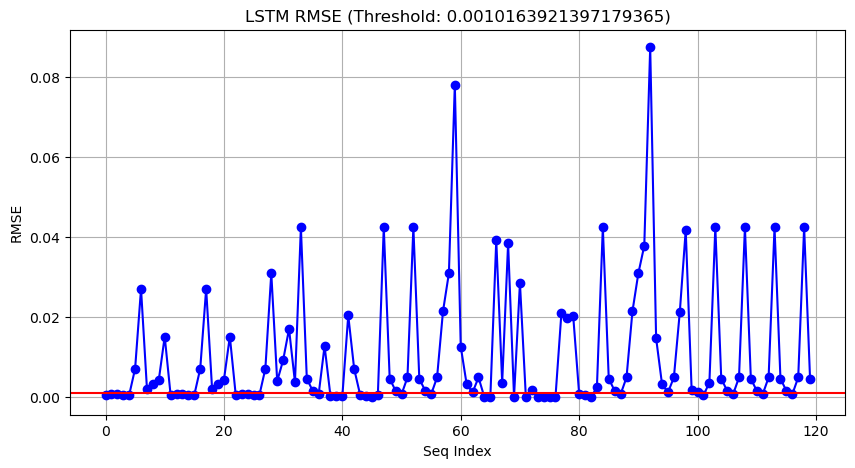

In [1]:
!pip install "numpy<2"
import numpy as np
import os
import torch 
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/Users/syeda/MobiWatch/src/ai/lstm/")

from encoder import Encoder
from lstm_multivariate import train, test
from utils import Normalizer, multiLSTM_seqformat
# from timeseries_multivariate import MultiTimeseriesAID 
import more_itertools  
from sklearn.metrics import roc_curve, auc


# train data
train_dataset = "5g-mobiwatch"
train_label = "benign"
delimeter = ";"

model_dict = torch.load(f'/Users/syeda/MobiWatch/src/ai/lstm/save/lstm_multivariate_{train_dataset}_{train_label}.pth.tar')
model = model_dict['net']
thres = model_dict['thres']
print(thres)

# test data
test_dataset = "5g-mobiwatch"
test_label = "abnormal"

if __name__ == "__main__":
    print(test_dataset, test_label)
    # Validate the performance of trained model
    data_folder = "/Users/syeda/MobiWatch/dataset/mobiflow"
    df = pd.read_csv(f'{data_folder}/{test_dataset}_{test_label}_mobiflow.csv', header=0, delimiter=delimeter)
    # Handle missing values
    df.fillna(0, inplace=True)

    sequence_length = 5
    encoder = Encoder()

    X_sequences = encoder.encode_mobiflow(df, sequence_length+1)
    print(X_sequences.shape)

    x_test = []
    y_test = []
    for i in range(len(X_sequences)):
        split_seq = np.split(X_sequences[i], sequence_length+1)
        x_test.append(split_seq[:sequence_length])
        y_test.append(split_seq[-1])

    x_test = np.asarray(x_test)
    y_test = np.asarray(y_test)
    print(x_test.shape)
    print(y_test.shape)

    # id_column_idx = [1, 2]
    # for x in X_test:
    #     for idx in id_column_idx:
    #         # handle TMSI = -1?
    #         if idx == 2:
    #             is_tmsi = True
    #         else:
    #             is_tmsi = False
    #         encoded_vals = encode_value_within_window(x[:, idx], is_tmsi)
    #         x[:, idx] = encoded_vals

    # Load original data for interpretation    
    # test_original = np.load(os.path.join('../../preprocessing/data/', "original", f"{test_dataset}_{test_label}_{test_ver}_data_before_encode.npy"))
    # X_original = more_itertools.windowed(test_original,n=seq_len,step=1)
    # X_original = np.asarray(list(X_original)[:-1])
    # y_original = np.asarray(test_original[seq_len:])
    
    # # Normalization
    # if normalize == True:
    #     # train data, normalizer
    #     train_feat = np.load('../../preprocessing/data/%s_%s_%s.npy' % (train_dataset, train_label, train_ver))
    #     normer = Normalizer(train_feat.shape[-1],online_minmax=True)
    #     train_feat = normer.fit_transform(train_feat)
    #     test_feat = normer.transform(test_feat)
    # print(test_feat.shape)

    # Inference
    rmse_vec = test(model, thres, x_test, y_test)

    # Convert back to DataFrame
    anomalies = torch.tensor(rmse_vec > thres)
    if len(anomalies) > 0:
        for anomalies_idx in torch.nonzero(anomalies).squeeze():
            df_idx = anomalies_idx
            sequence_data = df.loc[df_idx:df_idx + sequence_length]
            df_sequence = pd.DataFrame(sequence_data, columns=encoder.identifier_features + encoder.numerical_features + encoder.categorical_features)
            print(df_sequence)
            print()
    
    plot = True
    if plot:
        import matplotlib.pyplot as plt
        # Creating a simple line chart
        plt.figure(figsize=(10, 5))
        plt.plot(rmse_vec, marker='o', linestyle='-', color='b')  # Plotting the line chart
        plt.axhline(y=thres, color='r', linestyle='-') # threshold
        plt.title(f'LSTM RMSE (Threshold: {thres})')  # Title of the chart
        plt.xlabel('Seq Index')  # X-axis label
        plt.ylabel('RMSE')  # Y-axis label
        plt.grid(True)  # Adding a grid
        plt.savefig("test.png")  # Display the plot

    # ground truth
    gt = {"blind dos": [10, 21, 32], 
        "downlink dos": [38],
        "downlink imsi extr": [102],
        "uplink imsi extr": list(range(42, 47)),
        "uplink dos": [71, 72],
        "bts ddos": list(range(52, 64))+list(range(88, 97))+list(range(107, 125)),
        "null cipher": list(range(82, 84))
        }
    print([10, 21, 32])
    fn = [v for k in gt.keys() for v in gt[k]]
    fp = []

    # Convert back to DataFrame
    for anomalies_idx in torch.nonzero(anomalies).squeeze():
        df_idx = anomalies_idx
        sequence_data = df.loc[df_idx:df_idx + sequence_length]
        df_sequence = pd.DataFrame(sequence_data, columns=encoder.identifier_features + encoder.numerical_features + encoder.categorical_features)
        print(df_sequence)

        # evaluation with ground truth
        attack_found = False
        for attack in gt.keys():
            for attack_idx in gt[attack]:
                if anomalies_idx <= attack_idx <= anomalies_idx + sequence_length:
                    attack_found = True
                    if attack_idx in fn:
                        fn.remove(attack_idx) 
            if attack_found:
                break
        
        if attack_found:
            print(f"Attack: {attack}")
        else:
            print(f"False Positive")
            fp.append(anomalies_idx)

        print()

    print("FN:")
    print(fn)
    print("FP:")
    print(fp)

    POS = len([v for k in gt.keys() for v in gt[k]])
    NEG = x_test.shape[0] - POS
    FP = len(fp)
    FN = len(fn)
    TP = POS - FP
    TN = NEG - FN
    # Compute precision, recall and F1-measure
    acc = 100 * (TP + TN) / (TP + TN + FP + FN)
    P = 100 * TP / (TP + FP)
    R = 100 * TP / (TP + FN)
    F1 = 2 * P * R / (P + R)
    fpr = 100 * FP / (FP + TN)
    tpr = 100 * TP / (TP + FN)
    print('false positive (FP): {}, false negative (FN): {}, Acc: {:.3f}%, Precision: {:.3f}%, Recall: {:.3f}%, F1-measure: {:.3f}%'.format(FP, FN, acc, P, R, F1))
    print('false positive rate: {:.3f}%, true positive rate: {:.3f}%'.format(fpr, tpr))

    # plot_name = "test_plot_%s_%s_%s" % (test_dataset, test_label, test_ver)
    # test_plot(test_feat, rmse_vec, thres, plot_name)

    # print(X_original.__len__(), y_test.__len__())
    # i = 110
    # print(X_original[i], y_original[i], rmse_vec[i])
    # exit(0)

    # for i in range(X_original.__len__()):
    #     r = rmse_vec[i+seq_len-1]
    #     if r > thres:
    #         # abnormal
    #         x = X_original[i]
    #         print(x)
    #         y = y_original[i]
    #         print("==>")
    #         print(y)
    #         print()

    # normal_cnt = (rmse_vec <= thres).sum()
    # abnormal_cnt = (rmse_vec > thres).sum()

    # print(normal_cnt, abnormal_cnt)
    # # if test_label == "abnormal":
    # #     acc = abnormal_cnt / (normal_cnt + abnormal_cnt)
    # # else:
    # #     acc = normal_cnt / (normal_cnt + abnormal_cnt)
    # # print("Acc: %f" % acc)

    # # analysis
    # analysis = False
    # if not analysis:
    #     exit(0)
    # anomaly = test_feat[np.argsort(rmse_vec)[-100]]
    # idx = 100
    # seq_feat, interp_feat = multiLSTM_seqformat(test_feat, seq_len = seq_len, index=idx)

    # """Step 3: Create a DeepAID multivariate Time-Series Interpreter"""
    # feature_desc = json.load(open('../../preprocessing/data/desc/%s.json' % test_ver, "r")) # feature_description
    # my_interpreter = MultiTimeseriesAID(model,thres,input_size=100,feature_desc=feature_desc)

    # """Step 4: Interpret your anomaly and show the result"""
    # interpretation = my_interpreter(seq_feat)
    # my_interpreter.show_table(interp_feat,interpretation, normer)
    # my_interpreter.show_plot(interp_feat, interpretation, normer)
    # my_interpreter.show_heatmap(interp_feat,interpretation, normer)
    # print(interpretation)
    


In [2]:
print(test_dataset, test_label)

5g-mobiwatch abnormal


In [3]:
print(y_test)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [4]:
df.head()

,msg_type,msg_id,ts,ver,gen,bs_id,rnti,tmsi,imsi,imei,...,est_cause,msg,rrc_state,nas_state,sec_state,emm_cause,rrc_init_timer,rrc_inactive_timer,nas_initial_timer,nas_inactive_timer
0,UE,0,1.715199e+09,v2.0,SECSM,0,762,1777776,0,0,...,3,RRCSetupRequest,0,0,0,0,0.000000e+00,0,0.000000e+00,0.0
1,UE,1,1.715199e+09,v2.0,SECSM,0,762,1777776,0,0,...,3,RRCSetup,2,0,0,0,1.715199e+09,0,0.000000e+00,0.0
2,UE,2,1.715199e+09,v2.0,SECSM,0,762,1777776,2089900007487,0,...,3,RRCSetupComplete,2,0,0,0,1.715199e+09,0,0.000000e+00,0.0
3,UE,3,1.715199e+09,v2.0,SECSM,0,762,1777776,2089900007487,0,...,3,Registrationrequest,2,1,0,0,1.715199e+09,0,1.715199e+09,0.0
4,UE,4,1.715199e+09,v2.0,SECSM,0,762,1777776,2089900007487,0,...,3,Authenticationrequest,2,1,0,0,1.715199e+09,0,1.715199e+09,0.0


(956, 570)
Epoch [10/500], Loss: 0.005611
Epoch [20/500], Loss: 0.001036
Epoch [30/500], Loss: 0.000846
Epoch [40/500], Loss: 0.000553
Epoch [50/500], Loss: 0.000411
Epoch [60/500], Loss: 0.000504
Epoch [70/500], Loss: 0.000409
Epoch [80/500], Loss: 0.000459
Epoch [90/500], Loss: 0.000178
Epoch [100/500], Loss: 0.000054
Epoch [110/500], Loss: 0.000201
Epoch [120/500], Loss: 0.000128
Epoch [130/500], Loss: 0.000106
Epoch [140/500], Loss: 0.000162
Epoch [150/500], Loss: 0.000109
Epoch [160/500], Loss: 0.000043
Epoch [170/500], Loss: 0.000057
Epoch [180/500], Loss: 0.000088
Epoch [190/500], Loss: 0.000050
Epoch [200/500], Loss: 0.000075
Epoch [210/500], Loss: 0.000039
Epoch [220/500], Loss: 0.000038
Epoch [230/500], Loss: 0.000052
Epoch [240/500], Loss: 0.000043
Epoch [250/500], Loss: 0.000017
Epoch [260/500], Loss: 0.000009
Epoch [270/500], Loss: 0.000006
Epoch [280/500], Loss: 0.000007
Epoch [290/500], Loss: 0.000081
Epoch [300/500], Loss: 0.000100
Epoch [310/500], Loss: 0.000013
Epoch 

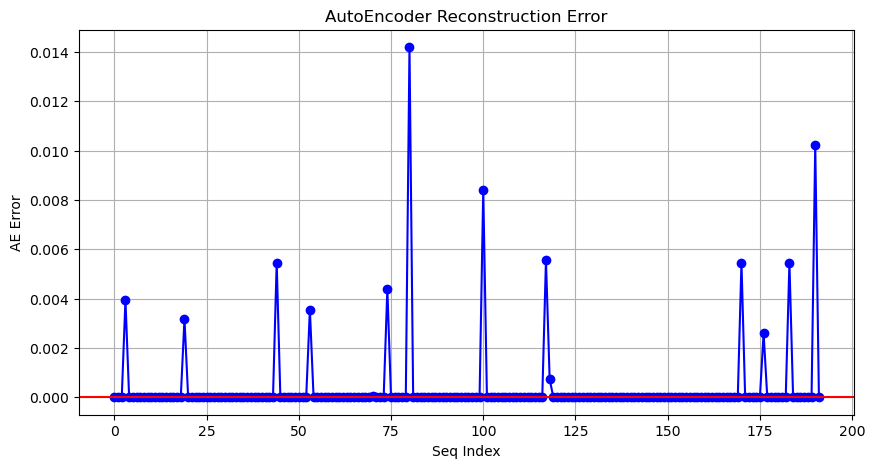

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
sys.path.append("/Users/syeda/MobiWatch/src/ai/autoencoder")
from model import Autoencoder
from encoder import Encoder

train_dataset = "5g-mobiwatch"
train_label = "benign"
delimeter = ";"

# Step 1: Load and preprocess data
data_folder = "/Users/syeda/MobiWatch/dataset/mobiflow"
df = pd.read_csv(f'{data_folder}/{train_dataset}_{train_label}_mobiflow.csv', header=0, delimiter=delimeter)
# Handle missing values
df.fillna(0, inplace=True)

sequence_length = 6
encoder = Encoder()
X_sequences = encoder.encode_mobiflow(df, sequence_length)
print(X_sequences.shape)

# Split data into training and test sets
seed = 2 # 42
indices = np.arange(X_sequences.shape[0])
val_portion = 0.2 # size of validation set
X_train, X_test, indices_train, indices_test = train_test_split(X_sequences, indices, test_size=val_portion, random_state=seed)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# Create DataLoader for training
train_dataset = TensorDataset(X_train, X_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Define the Autoencoder model
input_dim = X_train.shape[1]
model = Autoencoder(input_dim)

# Compile and train the model
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 500
for epoch in range(num_epochs):
    for data in train_loader:
        inputs, _ = data
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

# Save the model
model_path = "/Users/syeda/MobiWatch/src/ai/autoencoder/data/autoencoder_model.pth"

with torch.no_grad():
    reconstructions = model(X_train)
    reconstruction_error = torch.mean((X_train - reconstructions) ** 2, dim=1)
    percentile = 99
    threshold = np.percentile(reconstruction_error.numpy(), percentile) # we assume the training set contains X% anomalous data
    # alternative: (1) use maximum reconstruction error (2) take average

torch.save({'model': model, "threshold": threshold}, model_path)
print(f"Model saved to {model_path}")

# Detect anomalies
model.eval()

with torch.no_grad():
    reconstructions = model(X_test)
    reconstruction_error = torch.mean((X_test - reconstructions) ** 2, dim=1)

anomalies = reconstruction_error > threshold

# Convert back to DataFrame
if len(anomalies) > 0:
    for anomalies_idx in torch.nonzero(anomalies).squeeze():
        df_idx = indices_test[anomalies_idx]
        sequence_data = df.loc[df_idx:df_idx + sequence_length - 1]
        df_sequence = pd.DataFrame(sequence_data, columns=encoder.identifier_features + encoder.numerical_features + encoder.categorical_features)
        print(df_sequence)
        print()

# plot graph - reconstruction err w.r.t. to each sequence
plot = True
if plot:
    import matplotlib.pyplot as plt
    # Creating a simple line chart
    plt.figure(figsize=(10, 5))
    plt.plot(reconstruction_error, marker='o', linestyle='-', color='b')  # Plotting the line chart
    plt.axhline(y=threshold, color='r', linestyle='-') # threshold
    plt.title(f'AutoEncoder Reconstruction Error (Threshold: {threshold})')  # Title of the chart
    plt.title('AutoEncoder Reconstruction Error')  # Title of the chart
    plt.xlabel('Seq Index')  # X-axis label
    plt.ylabel('AE Error')  # Y-axis label
    plt.grid(True)  # Adding a grid
    plt.savefig("validation.png")  # Display the plot

## Output the anomalies
#anomalous_data = X_test[anomalies]

## Convert anomalous_data back to original form
#anomalous_data_numpy = anomalous_data.numpy()

# Reshape anomalous data back to original sequence shape
#num_features_per_line = len(numerical_features) + encoded_identifiers.shape[1] // len(identifier_features) + len(encoder.categories_[0])
#anomalous_data_reshaped = anomalous_data_numpy.reshape(-1, sequence_length, num_features_per_line)

## Inverse transform numerical features
#anomalous_data_num = scaler.inverse_transform(anomalous_data_reshaped[:, :, :len(numerical_features)].reshape(-1, len(numerical_features)))

## Inverse transform categorical features
#anomalous_data_cat = encoder.inverse_transform(anomalous_data_reshaped[:, :, len(numerical_features):].reshape(-1, len(encoder.categories_[0])))

## Combine numerical and categorical features
#anomalous_data_combined = np.hstack([anomalous_data_num, anomalous_data_cat])

## Convert back to DataFrame
#anomalous_data_list = []
#for i in range(0, anomalous_data_combined.shape[0], sequence_length):
    #sequence_data = anomalous_data_combined[i:i + sequence_length]
    #df_sequence = pd.DataFrame(sequence_data, columns=numerical_features + categorical_features)
    #anomalous_data_list.append(df_sequence)

#print("Anomalous data points in original form:")
#for anomalous_sequence in anomalous_data_list:
    #print(anomalous_sequence)
    #print()


In [6]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import sys
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from pathlib import Path
sys.path.append("/Users/syeda/MobiWatch/src/ai/autoencoder/encoding.py")
from encoding import nas_emm_code_NR, rrc_dl_ccch_code_NR, rrc_dl_dcch_code_NR, rrc_ul_ccch_code_NR, rrc_ul_dcch_code_NR

In [7]:
data = pd.read_csv("/Users/syeda/MobiWatch/dataset/mobiflow/new.csv", sep=';')

In [8]:
unique_rnti = data['rnti'].unique()

In [9]:
print(unique_rnti)

[16570 40822 62238 46811 56656 21357 44652  3554 27644 35084 57362 32284
 31095 13556 50422 39389 55426  5878 64718 39892 55731 56431 18054 48613
 45610 39381 20820 20612 38857 29920 43591 49332 10366 28593 58826 42108
 58803 35398  4070  7862 64620 47687 37255 40097 47933  7298 28772 35186
  6370 49554 21378 28832 12811 49032 34531 17599 61204 34438 12379 19065
 35627 14621 64415 59977 36741 35182  5548 11746 35037 17708 50504 47783
 10918 41601 24050 26760 17130 59479 46590 46713 55413 42264 48089 52892
 31179 27215 26273 28375 35647 58113 56520 64313 12023 25359 35835 63928
  6472 36440 13325 60485 30712   811 50248 43226 10424  9405 10888  6161
 54623 52234 61692 54479 63841 35768 46069  1544 42371 62104 42935 53367
 27460 51765 30154 54069 60802 42950 43636 10354 52850 57440 38680 22689
   762 63968 61850 53464 55410 51080 26168 50192 37847 16266 30195 53538
 43066 12056 33264 29295 47344  5008 38784 17134 62256 43597]


In [10]:
rnti_mapping = {rnti: idx for idx, rnti in enumerate(unique_rnti)}
rnti_mapped = data['rnti'].map(rnti_mapping)

In [11]:
#print(rnti_mapped)

In [12]:
data['rnti'] = rnti_mapped

In [13]:
unique_tmsi = data['tmsi'].unique()

In [14]:
tmsi_mapping = {tmsi: idx for idx, tmsi in enumerate(unique_tmsi)} # tmsi starting from 1
tmsi_mapping[0] = 0 # 0 tmsi is fixed
tmsi_mapped = data['tmsi'].map(tmsi_mapping)

In [15]:
pd.set_option('display.max_rows', None)

In [16]:
data.to_csv("new1.txt", sep=" ", index=False)

In [17]:
#df_diff = data.groupby('rnti')['ts'].agg(lambda x: x.max() - x.min()).reset_index()
#df_diff1 = data.groupby('rnti')['msg'].apply(list).reset_index()
#df_diff2 = data.groupby('rnti')['msg'].agg(lambda x: ', '.join(x.unique())).reset_index()
#df_diff4 = data.groupby('rnti')['Attackornot'].first()

In [18]:
#data2 = data.merge(df_diff, on='rnti', how='left')
#print(data2)

In [19]:
#pd.concat([df_diff, df_diff2, df_diff4], axis = 1)
#data1 = df_diff.merge(df_diff2, on="rnti", how="inner").merge(df_diff4, on="rnti", how="inner")

In [20]:
#from sklearn.preprocessing import OneHotEncoder
#encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
#encoded_array = encoder.fit_transform(data1[['msg']])

In [21]:
#from sklearn.preprocessing import MultiLabelBinarizer
#mlb = MultiLabelBinarizer()
#encoded_data = mlb.fit_transform(data1['msg'])
#encoded_df = pd.DataFrame(encoded_data, columns=mlb.classes_, index=data1.index)
#final_df = data1.join(encoded_df).drop(columns=['msg'])
#print(final_df)

In [22]:
data['ts'] = data.groupby('rnti')['ts'].transform(lambda x: x.max() - x.min())
#print(data['ts'])

In [23]:
unique_msg = data['msg'].unique()
print(unique_msg)

['RRCSetupRequest' 'RRCSetup' 'RRCSetupComplete' 'Registrationrequest'
 'Authenticationrequest' 'Authenticationresponse' 'Securitymodecommand'
 'Securitymodecomplete' 'SecurityModeCommand' 'SecurityModeComplete'
 'Registrationreject' 'Identityrequest' 'Identityresponse'
 'DeregistrationrequestUEoriginating' 'ULInformationTransfer'
 'LoggedMeasurementConfiguration-r16' 'RRCReconfigurationComplete'
 'MeasurementReport' 'MobilityFromNRCommand' 'SecurityModeFailure'
 'UECapabilityEnquiry']
